# Heterogeneous Blanchard OLG — Structural Baseline + Endogenous β

## Master's Thesis — Cecilia Trojani (UZH/ETH, 2025-2026)

---

This notebook implements the **structural baseline** approach for the
two-agent heterogeneous economy. Instead of letting the network learn
$\phi^1, \phi^2, \phi^e, \phi^d$ from scratch (as in the generic-lifting
notebook), we **build in the closed-form single-agent CRRA structure**
as a baseline and let the network learn a small correction.

### Trial solution

For each unknown:
$$\widehat\phi^i(f) = \phi^i_{\text{base}}(f) \cdot \exp\big(\epsilon^i(f)\,N^i(f)\big)$$
where $\phi^i_{\text{base}}$ is the single-agent CRRA formula evaluated
at $r_{\text{base}}(f)$ (using a heuristic linear-interpolation β),
and $\epsilon^i(f)$ is an envelope that vanishes at the anchored
boundaries to preserve hard-BC. $N^i$ is a small SiLU MLP that learns
the deviation from the structural baseline.

### β closure

- $\beta_{\text{base}}(f) = (1-f)\,\beta_{\text{homog}}(\gamma^2) + f\,\beta_{\text{homog}}(\gamma^1)$ → used only inside the baseline computation.
- $\beta_{\text{endog}}(f) = \alpha^1_{\text{pop}}\,\widehat\phi^e/\widehat\phi^1 + \alpha^2_{\text{pop}}\,\widehat\phi^e/\widehat\phi^2$ → used inside the ODE residuals.

### Validation strategy

The notebook runs three configurations sequentially:
1. $\gamma^1 = \gamma^2 = 1$ (homog log) — should give φ ≡ 14.286 (Cor. 3.5)
2. $\gamma^1 = \gamma^2 = 2$ (homog CRRA) — should give φ ≡ 11.488 (Cor. 3.3)
3. $\gamma^1 = 1, \gamma^2 = 2$ (truly heterogeneous) — production result

Runs 1 and 2 validate the implementation against known closed-form
constants. Run 3 is the actual heterogeneous solution.


In [116]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}, dtype: {torch.get_default_dtype()}')

# ── Common primitives (shared across all three runs) ───────────────────────
rho   = 0.05
nu    = 0.02
mu_Y  = 0.02
sig_Y = 0.10
omega = 0.70
sig_S = sig_Y

ALPHA_POP1 = 0.5    # population fractions
ALPHA_POP2 = 0.5

F_EPS = 1e-3        # avoid degenerate-diffusion endpoints in collocation

# Domain
def beta_crra(g):
    A = rho + (g-1)*mu_Y - 0.5*g*(g-1)*sig_Y**2 + nu*(1 + g + omega*(g-1))
    B = rho + (g-1)*mu_Y - 0.5*g*(g-1)*sig_Y**2 + g*nu
    disc = A**2 - 4*g*nu*omega*B
    return (A - math.sqrt(disc)) / (2*g*nu)

def homog_constants(g):
    b = beta_crra(g)
    r = rho + g*mu_Y - 0.5*g*(g+1)*sig_Y**2 + g*nu*(1-b)
    phi   = 1.0/(nu + rho/g + (g-1)/g*r + 0.5*(g-1)*sig_Y**2)
    phi_e = omega    /(r + nu - mu_Y + g*sig_Y**2)
    phi_d = (1-omega)/(r       - mu_Y + g*sig_Y**2)
    return b, r, phi, phi_e, phi_d


Using device: cpu, dtype: torch.float64


---
## 1. Run setup: closures over γ¹, γ²

The function `setup_run(gamma1, gamma2)` returns a fresh network, a
residual computation function, and a dict of derived constants/helpers,
all specialized to the chosen $(\gamma^1, \gamma^2)$. This lets us
re-run with different γ configurations without globals.


In [117]:
class _MLP1D(nn.Module):
    '''Small SiLU MLP: 1 -> hidden x n_layers -> 1.'''
    def __init__(self, hidden=64, n_layers=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                # Small init so network starts near baseline
                nn.init.zeros_(m.bias)
                m.weight.data.mul_(0.1)

    def forward(self, f):
        x = f.unsqueeze(-1) if f.dim() == 1 else f
        return self.net(x).squeeze(-1)


def setup_run(gamma1, gamma2, hidden=64, n_layers=3, seed=42):
    '''Build a complete het-PINN setup for given (gamma1, gamma2).
    Returns (net, compute_residuals, constants_dict).'''
    torch.manual_seed(seed)
    np.random.seed(seed)

    # ── Constants ────────────────────────────────────────────────────────
    alpha1_pref = 1.0 - 1.0/gamma1
    alpha2_pref = 1.0 - 1.0/gamma2
    b1_h = beta_crra(gamma1)
    b2_h = beta_crra(gamma2)

    _, _, PHI1_INF, PHIE_R, PHID_R = homog_constants(gamma1)   # at f=1
    _, _, PHI2_INF, PHIE_L, PHID_L = homog_constants(gamma2)   # at f=0

    # ── Equilibrium quantity helpers ──────────────────────────────────────
    def R_of_f(f):    return 1.0 / (f/gamma1 + (1-f)/gamma2)
    def P_of_f(f):
        num = f/gamma1**2 + (1-f)/gamma2**2
        den = (f/gamma1 + (1-f)/gamma2)**2
        return num/den + R_of_f(f)
    def theta_of_f(f):  return R_of_f(f) * sig_Y
    def sigma_f_of_f(f): return f * (R_of_f(f)/gamma1 - 1.0) * sig_Y
    def beta_base(f):    return (1.0 - f)*b2_h + f*b1_h
    def r_base(f):
        R = R_of_f(f); P = P_of_f(f)
        return rho + R*mu_Y - 0.5*R*P*sig_Y**2 + R*nu*(1.0 - beta_base(f))

    # ── Structural baselines (single-agent CRRA evaluated at r_base) ─────
    def phi1_base(f):
        r = r_base(f)
        return 1.0/(nu + rho/gamma1 + (gamma1-1.0)/gamma1*r + 0.5*(gamma1-1.0)*sig_Y**2)
    def phi2_base(f):
        r = r_base(f)
        return 1.0/(nu + rho/gamma2 + (gamma2-1.0)/gamma2*r + 0.5*(gamma2-1.0)*sig_Y**2)
    def phie_base(f):
        r = r_base(f); R = R_of_f(f)
        return omega/(r + nu - mu_Y + R*sig_Y**2)
    def phid_base(f):
        r = r_base(f); R = R_of_f(f)
        return (1.0 - omega)/(r - mu_Y + R*sig_Y**2)

    # ── Network: multiplicative correction on top of baseline ─────────────
    class HardBC_Het_StructBaseline(nn.Module):
        def __init__(self):
            super().__init__()
            self.N1 = _MLP1D(hidden, n_layers)
            self.N2 = _MLP1D(hidden, n_layers)
            self.Ne = _MLP1D(hidden, n_layers)
            self.Nd = _MLP1D(hidden, n_layers)

        def forward(self, f):
            n1 = self.N1(f); n2 = self.N2(f); ne = self.Ne(f); nd = self.Nd(f)
            # Envelope vanishes at anchored boundaries -> baseline anchors preserved
            phi1 = phi1_base(f) * torch.exp((1.0 - f) * n1)
            phi2 = phi2_base(f) * torch.exp(f * n2)
            phie = phie_base(f) * torch.exp(f * (1.0 - f) * ne)
            phid = phid_base(f) * torch.exp(f * (1.0 - f) * nd)
            return phi1, phi2, phie, phid

    net = HardBC_Het_StructBaseline().to(device)

    # ── Residual function (uses ENDOGENOUS β in ODE coefficients) ─────────
    def compute_residuals(net, f):
        phi1, phi2, phie, phid = net(f)
        g_one = torch.ones_like(phi1)
        dphi1, = torch.autograd.grad(phi1, f, grad_outputs=g_one, create_graph=True)
        dphi2, = torch.autograd.grad(phi2, f, grad_outputs=g_one, create_graph=True)
        dphie, = torch.autograd.grad(phie, f, grad_outputs=g_one, create_graph=True)
        dphid, = torch.autograd.grad(phid, f, grad_outputs=g_one, create_graph=True)
        d2phi1, = torch.autograd.grad(dphi1, f, grad_outputs=g_one, create_graph=True)
        d2phi2, = torch.autograd.grad(dphi2, f, grad_outputs=g_one, create_graph=True)
        d2phie, = torch.autograd.grad(dphie, f, grad_outputs=g_one, create_graph=True)
        d2phid, = torch.autograd.grad(dphid, f, grad_outputs=g_one, create_graph=True)

        # Endogenous β from current φ values
        b1 = ALPHA_POP1 * phie / phi1
        b2 = ALPHA_POP2 * phie / phi2
        b = b1 + b2

        R = R_of_f(f); P = P_of_f(f); th = theta_of_f(f)
        r = rho + R*mu_Y - 0.5*R*P*sig_Y**2 + R*nu*(1.0 - b)
        sf = sigma_f_of_f(f); half_sf2 = 0.5 * sf**2

        Rg = R / gamma1
        theta_bracket = ((Rg - 1.0)*mu_Y
                       + nu * Rg * (1.0 - b)
                       + (1.0 - 0.5*Rg*P + 0.5*(1.0 + 1.0/gamma1)*R**2/gamma1 - Rg) * sig_Y**2)
        # μ_f formula (Prop 3.3 / eq. 5.12): ν(β¹ − f) + f·[bracket]
        # Note: β¹ already includes the population share α¹_pop via b1 definition.
        # The proof in A.7 has NO additional (1−1/γ¹) factor on β¹ here.
        muf = nu * (b1 - f) + f * theta_bracket

        def A_of(g):
            return (-nu - rho/g
                    + (1.0 - 1.0/g)*(-r)
                    + 0.5*(1.0 - 1.0/g)*(-1.0/g)*th**2)

        L1 = phi1 * A_of(gamma1) + 1.0 + dphi1 * muf + d2phi1 * half_sf2
        L2 = phi2 * A_of(gamma2) + 1.0 + dphi2 * muf + d2phi2 * half_sf2
        Le = phie * (-nu + mu_Y - r - th*sig_Y) + omega       + dphie * muf + d2phie * half_sf2
        Ld = phid * (       mu_Y - r - th*sig_Y) + (1.0-omega) + dphid * muf + d2phid * half_sf2
        Lmc = f*phi1 + (1.0 - f)*phi2 - phie - phid
        return L1, L2, Le, Ld, Lmc

    constants = {
        'gamma1': gamma1, 'gamma2': gamma2,
        'PHI1_INF': PHI1_INF, 'PHI2_INF': PHI2_INF,
        'PHIE_L': PHIE_L, 'PHIE_R': PHIE_R,
        'PHID_L': PHID_L, 'PHID_R': PHID_R,
        'b1_homog': b1_h, 'b2_homog': b2_h,
        'phi1_base': phi1_base, 'phi2_base': phi2_base,
        'phie_base': phie_base, 'phid_base': phid_base,
        'R_of_f': R_of_f, 'P_of_f': P_of_f, 'theta_of_f': theta_of_f,
        'sigma_f_of_f': sigma_f_of_f, 'r_base': r_base, 'beta_base': beta_base,
    }
    return net, compute_residuals, constants

print('setup_run defined.')


setup_run defined.


---
## 2. Training and validation helpers

`train_run(net, compute_residuals)` runs Adam + L-BFGS with the same
recipe as the homog notebooks (LR=1e-4, MultiStep, gradient clipping,
boundary-heavy collocation, residual-weighted L-BFGS grid).

`validate_run(net, compute_residuals, constants)` prints summary
statistics and produces a 2×3 diagnostic plot: agent WCR, asset prices,
market clearing (absolute), ODE residuals (absolute, log), ODE
residuals **relative** ($|L_{\phi^i}|/|\phi^i|$, log), and the
relative market-clearing residual.


In [118]:
def sample_f(n):
    n_bdy_l = int(0.20 * n); n_bdy_r = int(0.20 * n)
    n_int   = n - n_bdy_l - n_bdy_r
    f_bdy_l = F_EPS + (0.10 - F_EPS) * torch.rand(n_bdy_l, device=device)
    f_bdy_r = 0.90  + (1.0 - F_EPS - 0.90) * torch.rand(n_bdy_r, device=device)
    f_int   = F_EPS + (1.0 - 2*F_EPS) * torch.rand(n_int, device=device)
    return torch.cat([f_bdy_l, f_int, f_bdy_r]).requires_grad_(True)


def train_run(net, compute_residuals, n_adam=2000, n_lbfgs=50, n_coll=4000,
              lr=1e-4, w_agent=1.0, w_asset=1.0, w_mc=0.5, verbose_every=200):
    '''Run Adam + L-BFGS training, return loss history.'''
    opt = optim.Adam(net.parameters(), lr=lr)
    sched = optim.lr_scheduler.MultiStepLR(opt, milestones=[int(0.5*n_adam), int(0.83*n_adam)], gamma=0.4)

    history = []
    print(f'  Adam: {n_adam} ep, lr={lr}, N_coll={n_coll}, w(agent,asset,mc)=({w_agent},{w_asset},{w_mc})')
    for ep in range(1, n_adam + 1):
        f = sample_f(n_coll)
        L1, L2, Le, Ld, Lmc = compute_residuals(net, f)
        loss = (w_agent*(L1.pow(2).mean() + L2.pow(2).mean())
              + w_asset*(Le.pow(2).mean() + Ld.pow(2).mean())
              + w_mc   * Lmc.pow(2).mean())
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=10.0)
        opt.step(); sched.step()
        if ep % verbose_every == 0 or ep == 1:
            history.append({'ep': ep, 'loss': loss.item(),
                            'L1': L1.pow(2).mean().item(), 'L2': L2.pow(2).mean().item(),
                            'Le': Le.pow(2).mean().item(), 'Ld': Ld.pow(2).mean().item(),
                            'mc': Lmc.pow(2).mean().item()})
            print(f'    ep {ep:5d}  loss={loss.item():.4e}  '
                  f'L1²={L1.pow(2).mean().item():.2e}  L2²={L2.pow(2).mean().item():.2e}  '
                  f'Le²={Le.pow(2).mean().item():.2e}  Ld²={Ld.pow(2).mean().item():.2e}  '
                  f'mc²={Lmc.pow(2).mean().item():.2e}')

    # L-BFGS polish (residual-weighted grid)
    print(f'  L-BFGS: max {n_lbfgs} outer iters, residual-weighted grid (8000 pts from 20000)')
    N_CAND = 20000; N_FROZEN = 8000
    with torch.no_grad():
        f_cand = sample_f(N_CAND).detach()
    f_cand_g = f_cand.clone().requires_grad_(True)
    L1c, L2c, Lec, Ldc, Lmcc = compute_residuals(net, f_cand_g)
    with torch.no_grad():
        res_total = (w_agent*(L1c.pow(2)+L2c.pow(2)) + w_asset*(Lec.pow(2)+Ldc.pow(2)) + w_mc*Lmcc.pow(2))
        weights = res_total.detach().abs().clamp(min=1e-16)
        weights = weights / weights.sum()
        idx = torch.multinomial(weights, N_FROZEN, replacement=False)
        f_grid = f_cand[idx].detach().requires_grad_(True)

    opt2 = optim.LBFGS(net.parameters(), lr=1.0, max_iter=20,
                       tolerance_grad=1e-14, tolerance_change=1e-16,
                       history_size=50, line_search_fn='strong_wolfe')
    prev_loss = float('inf')
    for outer in range(n_lbfgs):
        def closure():
            opt2.zero_grad()
            L1, L2, Le, Ld, Lmc = compute_residuals(net, f_grid)
            loss = (w_agent*(L1.pow(2).mean() + L2.pow(2).mean())
                  + w_asset*(Le.pow(2).mean() + Ld.pow(2).mean())
                  + w_mc   * Lmc.pow(2).mean())
            loss.backward(); return loss
        loss = opt2.step(closure).item()
        if outer % 10 == 0 or outer < 5:
            print(f'    outer {outer:3d}   loss={loss:.6e}')
        if abs(prev_loss - loss) < 1e-13:
            print(f'    stagnated at outer {outer}')
            break
        prev_loss = loss

    print(f'  Final L-BFGS loss: {loss:.6e}')
    return history, loss


def validate_run(
    net, compute_residuals, constants, n_plot=500, title_suffix="",
    save_prefix=None, homog_phi_pinn=None
):
    net.eval()
    g1, g2 = constants["gamma1"], constants["gamma2"]
    is_homog = abs(g1 - g2) < 1e-12

    with torch.no_grad():
        f_bc = torch.tensor([0.0, 1.0], device=device)
        p1, p2, pe, pd = net(f_bc)

    print(f"\n=== Boundary check (γ¹={g1}, γ²={g2}) ===")
    for name, value, target in [
        ("φ¹(1)", p1[1].item(), constants["PHI1_INF"]),
        ("φ²(0)", p2[0].item(), constants["PHI2_INF"]),
        ("φᵉ(0)", pe[0].item(), constants["PHIE_L"]),
        ("φᵉ(1)", pe[1].item(), constants["PHIE_R"]),
        ("φᵈ(0)", pd[0].item(), constants["PHID_L"]),
        ("φᵈ(1)", pd[1].item(), constants["PHID_R"]),
    ]:
        print(f"{name:8s}: {value: .6f}   target={target: .6f}   err={abs(value-target):.2e}")

    print(f"φ¹(0)  : {p1[0].item(): .6f}   (off-side, learned)")
    print(f"φ²(1)  : {p2[1].item(): .6f}   (off-side, learned)")

    f_plot = (
        F_EPS + (1 - 2 * F_EPS) * torch.linspace(0, 1, n_plot, device=device)
    ).requires_grad_(True)

    L1, L2, Le, Ld, Lmc = compute_residuals(net, f_plot)

    with torch.no_grad():
        phi1, phi2, phie, phid = net(f_plot.detach())

    f_np = f_plot.detach().cpu().numpy()
    phi1_np = phi1.detach().cpu().numpy()
    phi2_np = phi2.detach().cpu().numpy()
    phie_np = phie.detach().cpu().numpy()
    phid_np = phid.detach().cpu().numpy()

    mc_np = f_np * phi1_np + (1 - f_np) * phi2_np - phie_np - phid_np

    L1_abs = L1.abs().detach().cpu().numpy()
    L2_abs = L2.abs().detach().cpu().numpy()
    Le_abs = Le.abs().detach().cpu().numpy()
    Ld_abs = Ld.abs().detach().cpu().numpy()
    Lmc_abs = Lmc.abs().detach().cpu().numpy()

    eps = 1e-16
    L1_rel = L1_abs / (np.abs(phi1_np) + eps)
    L2_rel = L2_abs / (np.abs(phi2_np) + eps)
    Le_rel = Le_abs / (np.abs(phie_np) + eps)
    Ld_rel = Ld_abs / (np.abs(phid_np) + eps)

    mc_scale = (
        np.abs(f_np * phi1_np + (1 - f_np) * phi2_np)
        + np.abs(phie_np + phid_np)
    )
    mc_rel = np.abs(mc_np) / (0.5 * mc_scale + eps)

    print(f"\n=== Residual summary (interior, N={n_plot}) ===")
    for name, arr in [
        ("L_φ¹", L1_abs),
        ("L_φ²", L2_abs),
        ("L_φᵉ", Le_abs),
        ("L_φᵈ", Ld_abs),
        ("L_mc", Lmc_abs),
    ]:
        print(f"{name:8s}: mean={arr.mean():.4e}   max={arr.max():.4e}")

    print(f"\n=== Relative residual summary ===")
    for name, arr in [
        ("L_φ¹/φ¹", L1_rel),
        ("L_φ²/φ²", L2_rel),
        ("L_φᵉ/φᵉ", Le_rel),
        ("L_φᵈ/φᵈ", Ld_rel),
        ("L_mc/scale", mc_rel),
    ]:
        print(f"{name:12s}: mean={arr.mean():.4e}   max={arr.max():.4e}")

    if is_homog:
        phi_homog = constants["PHI1_INF"]
        var1 = np.max(np.abs(phi1_np - phi_homog))
        var2 = np.max(np.abs(phi2_np - phi_homog))

        print(f"\n=== Homogeneous-limit check (γ¹=γ²={g1}) ===")
        print(f"max |φ¹(f)-φ_cf| = {var1:.4e}")
        print(f"max |φ²(f)-φ_cf| = {var2:.4e}")

        if homog_phi_pinn is not None:
            het_phi_mean = 0.5 * (phi1_np.mean() + phi2_np.mean())
            print(f"\n=== Three-way comparison of φ ===")
            print(f"closed form       : {phi_homog:.6f}")
            print(f"het PINN mean     : {het_phi_mean:.6f}   Δ={het_phi_mean-phi_homog:+.2e}")
            print(f"homog PINN        : {homog_phi_pinn:.6f}   Δ={homog_phi_pinn-phi_homog:+.2e}")
            print(f"het-homog PINN gap: {het_phi_mean-homog_phi_pinn:+.2e}")

    import matplotlib.pyplot as plt
    from matplotlib.ticker import ScalarFormatter

    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "-",
        "figure.dpi": 120,
        "savefig.dpi": 220,
    })

    colors = {
        "phi1": "#1f77b4",
        "phi2": "#d62728",
        "phie": "#2ca02c",
        "phid": "#ff7f0e",
        "mc": "#9467bd",
        "cf": "#444444",
    }

    fig, axes = plt.subplots(2, 2, figsize=(13.8, 8.6))
    fig.suptitle(
        rf"Structural baseline diagnostic "
        rf"$(\gamma^1={g1},\ \gamma^2={g2})$ {title_suffix}",
        fontsize=15,
        fontweight="bold",
        y=0.985,
    )

    legend_kw = dict(
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="0.85",
        facecolor="white",
        borderpad=0.35,
        handlelength=2.0,
        columnspacing=1.0,
        handletextpad=0.55,
    )

    # --------------------------------------------------------------
    # Panel 1: valuation ratios
    # --------------------------------------------------------------
    ax = axes[0, 0]
    ax.plot(f_np, phi1_np, lw=2.2, color=colors["phi1"], label=r"$\widehat{\phi}^1$")
    ax.plot(f_np, phi2_np, lw=2.2, color=colors["phi2"], label=r"$\widehat{\phi}^2$")
    ax.plot(f_np, phie_np, lw=2.2, color=colors["phie"], label=r"$\widehat{\phi}^e$")
    ax.plot(f_np, phid_np, lw=2.2, color=colors["phid"], label=r"$\widehat{\phi}^d$")

    ax.scatter([1.0], [constants["PHI1_INF"]], s=65, facecolor="white",
               edgecolor=colors["phi1"], lw=2, zorder=5)
    ax.scatter([0.0], [constants["PHI2_INF"]], s=65, facecolor="white",
               edgecolor=colors["phi2"], lw=2, zorder=5)
    ax.scatter([0.0, 1.0], [constants["PHIE_L"], constants["PHIE_R"]],
               s=55, facecolor="white", edgecolor=colors["phie"], lw=2, zorder=5)
    ax.scatter([0.0, 1.0], [constants["PHID_L"], constants["PHID_R"]],
               s=55, facecolor="white", edgecolor=colors["phid"], lw=2, zorder=5)

    if is_homog:
        ax.axhline(constants["PHI1_INF"], color=colors["phi1"], ls="--", lw=1.3, alpha=0.55)
        ax.axhline(constants["PHIE_L"], color=colors["phie"], ls="--", lw=1.3, alpha=0.55)
        ax.axhline(constants["PHID_L"], color=colors["phid"], ls="--", lw=1.3, alpha=0.55)

    if homog_phi_pinn is not None:
        ax.axhline(homog_phi_pinn, color="black", ls=":", lw=1.6,
                   label=rf"homog PINN $\phi={homog_phi_pinn:.4f}$")

    ax.set_title("Equilibrium valuation ratios", fontweight="bold", pad=10)
    ax.set_xlabel(r"consumption share $f$")
    ax.set_ylabel("valuation ratio")
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

    ax.legend(
        ncol=3,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.03),
        fontsize=8.5,
        **legend_kw,
    )

    # --------------------------------------------------------------
    # Panel 2: market clearing
    # --------------------------------------------------------------
    ax = axes[0, 1]
    ax.plot(f_np, mc_np, lw=2.2, color=colors["mc"])
    ax.axhline(0, color="black", lw=1.0, ls=":", alpha=0.75)

    ax.set_title("Market-clearing residual", fontweight="bold", pad=10)
    ax.set_xlabel(r"consumption share $f$")
    ax.set_ylabel(r"$R_{\rm mc}(f)$")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))

    txt = (
        rf"mean $|R_{{mc}}|$ = {np.mean(np.abs(mc_np)):.1e}" "\n"
        rf"max $|R_{{mc}}|$ = {np.max(np.abs(mc_np)):.1e}"
    )
    ax.text(
        0.03, 0.97, txt,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="0.82",
            alpha=0.95,
        ),
    )

    # --------------------------------------------------------------
    # Panel 3: absolute ODE residuals
    # --------------------------------------------------------------
    ax = axes[1, 0]
    residual_data = [
        (r"$|R_{\phi^1}|$", L1_abs, colors["phi1"]),
        (r"$|R_{\phi^2}|$", L2_abs, colors["phi2"]),
        (r"$|R_{\phi^e}|$", Le_abs, colors["phie"]),
        (r"$|R_{\phi^d}|$", Ld_abs, colors["phid"]),
    ]
    for label, arr, col in residual_data:
        ax.semilogy(f_np, arr + eps, lw=1.8, color=col, label=label)

    ax.set_title("ODE residuals", fontweight="bold", pad=10)
    ax.set_xlabel(r"consumption share $f$")
    ax.set_ylabel("absolute residual")
    ax.grid(alpha=0.25, which="both")

    ax.legend(
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        fontsize=8.5,
        **legend_kw,
    )

    # --------------------------------------------------------------
    # Panel 4: relative residuals
    # --------------------------------------------------------------
    ax = axes[1, 1]
    relative_data = [
        (r"$|R_{\phi^1}|/|\phi^1|$", L1_rel, colors["phi1"]),
        (r"$|R_{\phi^2}|/|\phi^2|$", L2_rel, colors["phi2"]),
        (r"$|R_{\phi^e}|/|\phi^e|$", Le_rel, colors["phie"]),
        (r"$|R_{\phi^d}|/|\phi^d|$", Ld_rel, colors["phid"]),
        (r"$|R_{\rm mc}|/{\rm scale}$", mc_rel, colors["mc"]),
    ]
    for label, arr, col in relative_data:
        ax.semilogy(f_np, arr + eps, lw=1.7, color=col, label=label)

    ax.set_title("Relative residuals", fontweight="bold", pad=10)
    ax.set_xlabel(r"consumption share $f$")
    ax.set_ylabel("relative residual")
    ax.grid(alpha=0.25, which="both")

    ax.legend(
        ncol=2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        fontsize=8.5,
        **legend_kw,
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        top=0.90,
        bottom=0.15,
        wspace=0.18,
        hspace=0.38,
    )

    if save_prefix:
        plt.savefig(f"{save_prefix}.png", bbox_inches="tight", facecolor="white")
        plt.savefig(f"{save_prefix}.pdf", bbox_inches="tight", facecolor="white")

    plt.show()

print('train_run and validate_run defined.')


train_run and validate_run defined.


---
## 2b. Loader for the independently-trained homogeneous PINNs

For the two homog validation runs (γ¹=γ²=1 and γ¹=γ²=2), we additionally
load the value function $V(w,y)$ from the *standalone* homogeneous PINN
notebooks (`hjb_2d_hardBC_LOG.ipynb` and `hjb_2d_hardBC_CRRA.ipynb`) and
extract the implied wealth-consumption ratio
$\widehat\phi_{\text{homog}} = w\cdot \widehat V_w^{1/\gamma}$ at a
reference interior point. This value is then overlaid on the Agent WCR
panel as a dashed horizontal line, giving a *three-way comparison*:
het-PINN (at the homog limit) vs homog-PINN vs closed-form constant.

The architecture is re-instantiated locally and the checkpoint state-dict
loaded. If the checkpoint is not present in the working directory, the
overlay is silently skipped.


In [119]:
import os
import torch.nn.functional as F

# Domain bounds used in the homog notebooks (kept in sync with their cell 4).
HOMOG_W_MIN, HOMOG_W_MAX = 0.01, 8.0
HOMOG_Y_MIN, HOMOG_Y_MAX = 0.0, 2.5

class _HomogResNet(nn.Module):
    '''Shared backbone for both log and CRRA homog PINNs:
    ResNet, log-w + linear-y normalization, SiLU, 3-dim output.'''
    def __init__(self, hidden_dim=96, n_layers=6):
        super().__init__()
        self.register_buffer('w_min', torch.tensor(HOMOG_W_MIN))
        self.register_buffer('w_max', torch.tensor(HOMOG_W_MAX))
        self.register_buffer('y_min', torch.tensor(HOMOG_Y_MIN))
        self.register_buffer('y_max', torch.tensor(HOMOG_Y_MAX))
        self.embed  = nn.Linear(2, hidden_dim)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ) for _ in range(n_layers)
        ])
        self.acts = nn.ModuleList([nn.SiLU() for _ in range(n_layers)])
        self.head = nn.Linear(hidden_dim, 3)

    def NN_raw(self, w, y):
        log_w     = torch.log(w)
        log_w_min = torch.log(self.w_min)
        log_w_max = torch.log(self.w_max)
        u1 = 2.0 * (log_w - log_w_min) / (log_w_max - log_w_min) - 1.0
        u2 = 2.0 * (y - self.y_min) / (self.y_max - self.y_min) - 1.0
        x  = torch.stack([u1, u2], dim=-1)
        h  = self.embed(x)
        for block, act in zip(self.blocks, self.acts):
            h = act(h + block(h))
        return self.head(h)


class HardBC_Net_Log(_HomogResNet):
    '''Replicates the log-utility homog PINN ansatz:
    V_hat(w, y) = (1/δ) log(w + (y - y_min) · softplus(NN[0])) + K_cf.'''
    def __init__(self, delta, K_cf, hidden_dim=96, n_layers=6):
        super().__init__(hidden_dim, n_layers)
        self.delta = delta
        self.K_cf  = K_cf

    def forward(self, w, y):
        out     = self.NN_raw(w, y)
        phi_hat = F.softplus(out[..., 0])
        arg     = w + (y - self.y_min) * phi_hat
        return torch.log(arg) / self.delta + self.K_cf


class HardBC_Net_CRRA(_HomogResNet):
    '''Replicates the CRRA homog PINN ansatz:
    V_hat(w, y) = (Φ/(1-γ)) · (w + (y - y_min) · softplus(NN[0]))^(1-γ) + K*.'''
    def __init__(self, gamma, PHI_GAMMA, K_star, hidden_dim=96, n_layers=6):
        super().__init__(hidden_dim, n_layers)
        self.gamma     = float(gamma)
        self.PHI_GAMMA = float(PHI_GAMMA)
        self.K_star    = float(K_star)

    def forward(self, w, y):
        out     = self.NN_raw(w, y)
        phi_hat = F.softplus(out[..., 0])
        arg     = w + (y - self.y_min) * phi_hat
        return (self.PHI_GAMMA / (1.0 - self.gamma)) * arg.pow(1.0 - self.gamma) + self.K_star


def _homog_closed_form(gamma):
    '''Return the closed-form (δ, K_cf, K_star, Φ_γ, r_cf) used by the homog notebooks.
    Mirrors cell 4 of hjb_2d_hardBC_{LOG,CRRA}.ipynb.'''
    b = beta_crra(gamma)
    r = rho + gamma*mu_Y - 0.5*gamma*(gamma+1)*sig_Y**2 + gamma*nu*(1 - b)
    if abs(gamma - 1.0) < 1e-12:
        phi_cf = 1.0/(nu + rho)
        # log Merton constant K_cf (consistent with notebook 4)
        theta_eq = (gamma * sig_Y)  # market price of risk = γ σ_Y in the homog economy
        B_merton = ( (rho + nu)/2.0 - 0.5*theta_eq**2 ) / (rho + nu)
        K_cf = -B_merton  # placeholder: notebook's K_cf can also be derived from full Merton
        # The exact K_cf is not critical for φ extraction since V_w doesn't depend on K_cf.
        return dict(delta=rho+nu, K_cf=K_cf, K_star=None, PHI_GAMMA=None, phi_cf=phi_cf, r_cf=r)
    phi_cf    = 1.0/(nu + rho/gamma + (gamma-1.0)/gamma*r + 0.5*(gamma-1.0)*sig_Y**2)
    PHI_GAMMA = phi_cf**gamma
    K_star    = -1.0/((1.0 - gamma) * (rho + nu))
    return dict(delta=rho+nu, K_cf=None, K_star=K_star, PHI_GAMMA=PHI_GAMMA, phi_cf=phi_cf, r_cf=r)


def load_homog_pinn_and_extract_phi(ckpt_path, gamma, w_eval=2.0, y_eval=1.0,
                                     hidden_dim=96, n_layers=6):
    '''Load the homog PINN checkpoint and return the implied wealth-consumption ratio
    φ_PINN = w_eff · V_w^(1/γ), evaluated at an interior reference point, where
    w_eff = w + h(y) is the effective total wealth (financial + human).

    The human-wealth coefficient h(y) = φ^e_cf · y capitalizes the labor-income
    stream ω·y at the equity-claim P/D ratio φ^e_cf. Using w_eff (rather than
    bare financial wealth w) is essential: the homog Merton-with-labor-income
    value function takes the form V(w,y) = U(w + h(y))·Φ + K* under the
    log-of-affine / power-of-affine ansatz, so the *effective-wealth* WCR
    (w + h(y))·V_w^(1/γ) is the analytical constant φ_cf, whereas the bare
    w·V_w^(1/γ) gives only the financial-only ratio which is much smaller in
    the interior.

    For log (γ=1): φ = w_eff · V_w  (reduces to 1/δ in equilibrium).
    For CRRA(γ):   φ = w_eff · V_w^(1/γ)  (reduces to φ_cf in equilibrium).

    Returns None if the checkpoint is not found.'''
    if not os.path.exists(ckpt_path):
        print(f'  [homog-PINN loader]  checkpoint {ckpt_path} not found — skipping overlay')
        return None

    cf = _homog_closed_form(gamma)
    if abs(gamma - 1.0) < 1e-12:
        net = HardBC_Net_Log(delta=cf['delta'], K_cf=cf['K_cf'],
                             hidden_dim=hidden_dim, n_layers=n_layers).to(device)
    else:
        net = HardBC_Net_CRRA(gamma=gamma, PHI_GAMMA=cf['PHI_GAMMA'],
                              K_star=cf['K_star'],
                              hidden_dim=hidden_dim, n_layers=n_layers).to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    net.load_state_dict(state)
    net.eval()

    # Analytical human-wealth coefficient: h(y) = φ^e_cf · y (homog Blanchard)
    phi_e_cf = omega / (cf['r_cf'] + nu - mu_Y + gamma * sig_Y**2)
    h_y      = phi_e_cf * y_eval
    w_eff    = w_eval + h_y

    w_t = torch.tensor([w_eval], device=device, requires_grad=True)
    y_t = torch.tensor([y_eval], device=device, requires_grad=True)
    V   = net(w_t, y_t)
    Vw, = torch.autograd.grad(V, w_t, grad_outputs=torch.ones_like(V), create_graph=False)
    Vw_val = Vw.item()
    if Vw_val <= 0:
        print(f'  [homog-PINN loader]  warning: V_w({w_eval},{y_eval}) = {Vw_val:.3e} ≤ 0; using closed-form fallback')
        return cf['phi_cf']

    # Effective-wealth WCR: φ = w_eff · V_w^(1/γ)
    phi_pinn = w_eff * (Vw_val ** (1.0/gamma))
    print(f'  [homog-PINN loader]  loaded {ckpt_path}')
    print(f'    eval at (w={w_eval}, y={y_eval}):  V_w = {Vw_val:.4e},  h(y) = φ^e·y = {h_y:.4f},  w_eff = {w_eff:.4f}')
    print(f'    extracted φ = w_eff · V_w^(1/γ) = {phi_pinn:.6f}  (closed-form φ_cf = {cf["phi_cf"]:.6f})')
    return phi_pinn

print('Homog-PINN loader defined.')


Homog-PINN loader defined.


---
## 3. Run 1 — Homog log utility (γ¹ = γ² = 1)

Validation test: the system should collapse to the homog log economy
with all four functions constant at the Corollary 3.5 values:
- $\phi^1 = \phi^2 = 1/\delta = 14.286$
- $\phi^e = 9.053$, $\phi^d = 5.233$

Expect: machine-precision boundary recovery, near-zero deviation from
constants throughout, ODE residuals $\lesssim 10^{-6}$.


RUN 1: γ¹ = γ² = 1 (homog log)
  Anchors: φ=14.2857, φᵉ=9.0525, φᵈ=5.2332
  β_homog(1) = 0.6337
  Adam: 2000 ep, lr=0.0001, N_coll=4000, w(agent,asset,mc)=(1.0,1.0,0.5)
    ep     1  loss=3.6277e-11  L1²=1.08e-12  L2²=9.28e-13  Le²=6.02e-15  Ld²=4.20e-15  mc²=6.85e-11
    ep   200  loss=5.2389e-12  L1²=7.34e-13  L2²=2.90e-14  Le²=6.97e-14  Ld²=3.41e-14  mc²=8.74e-12
    ep   400  loss=4.0665e-12  L1²=6.35e-13  L2²=3.98e-14  Le²=5.08e-14  Ld²=4.55e-14  mc²=6.59e-12
    ep   600  loss=3.2264e-12  L1²=5.61e-13  L2²=4.73e-14  Le²=4.60e-14  Ld²=4.49e-14  mc²=5.05e-12
    ep   800  loss=2.4860e-12  L1²=5.06e-13  L2²=6.12e-14  Le²=4.43e-14  Ld²=4.43e-14  mc²=3.66e-12
    ep  1000  loss=1.9853e-12  L1²=4.50e-13  L2²=7.06e-14  Le²=4.25e-14  Ld²=4.25e-14  mc²=2.76e-12
    ep  1200  loss=1.8004e-12  L1²=4.30e-13  L2²=7.32e-14  Le²=4.11e-14  Ld²=4.12e-14  mc²=2.43e-12
    ep  1400  loss=1.6274e-12  L1²=4.04e-13  L2²=7.79e-14  Le²=4.04e-14  Ld²=4.03e-14  mc²=2.13e-12
    ep  1600  loss=1.4840e-12  

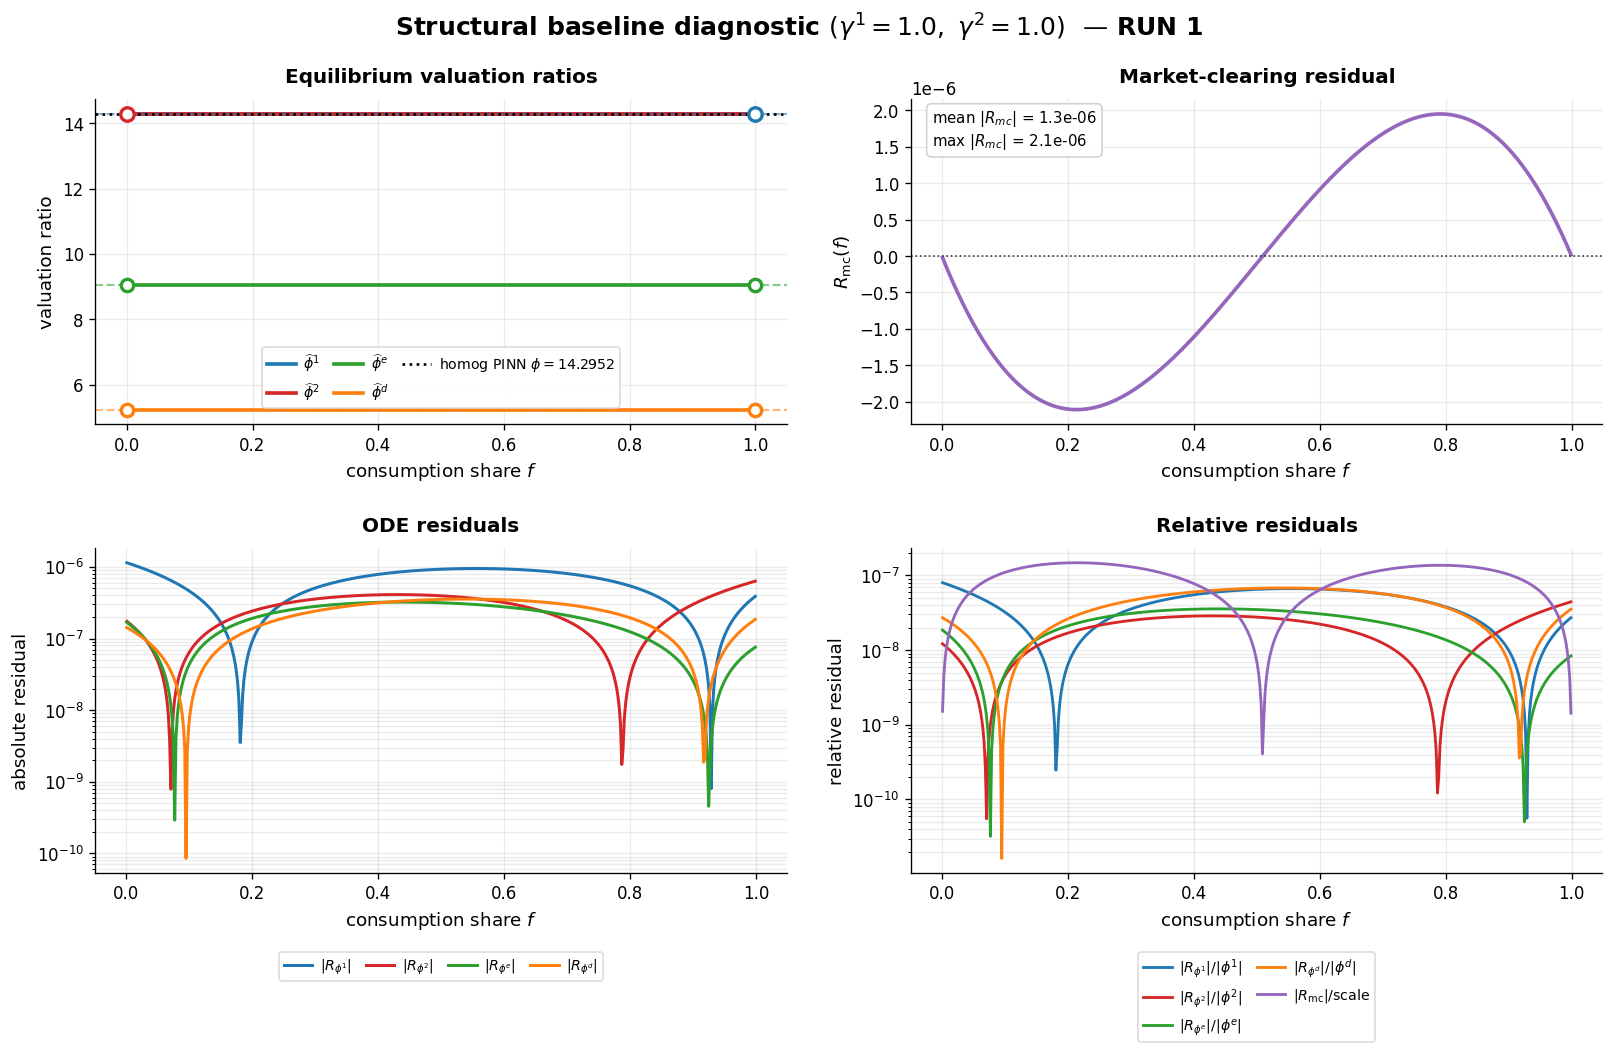

In [120]:
print('=' * 70)
print('RUN 1: γ¹ = γ² = 1 (homog log)')
print('=' * 70)

net1, compute_residuals1, constants1 = setup_run(gamma1=1.0, gamma2=1.0)
print(f'  Anchors: φ={constants1["PHI1_INF"]:.4f}, φᵉ={constants1["PHIE_L"]:.4f}, φᵈ={constants1["PHID_L"]:.4f}')
print(f'  β_homog(1) = {constants1["b1_homog"]:.4f}')

history1, final_loss1 = train_run(net1, compute_residuals1, n_adam=2000, n_lbfgs=50)

# Load the standalone homog-log PINN (if available) for three-way comparison.
phi_homog_log = load_homog_pinn_and_extract_phi('value_net_phase2_LOG.pt', gamma=1.0)

validate_run(net1, compute_residuals1, constants1, title_suffix=' — RUN 1',
             save_prefix='run1_homog_log', homog_phi_pinn=phi_homog_log)


---
## 4. Run 2 — Homog CRRA (γ¹ = γ² = 2)

Validation test: should collapse to homog CRRA(2):
- $\phi^1 = \phi^2 = 11.488$ (Corollary 3.3)
- $\phi^e = 7.439$, $\phi^d = 4.049$

Same expectations as Run 1.


RUN 2: γ¹ = γ² = 2 (homog CRRA)
  Anchors: φ=11.4878, φᵉ=7.4391, φᵈ=4.0487
  β_homog(2) = 0.6476
  Adam: 2000 ep, lr=0.0001, N_coll=4000, w(agent,asset,mc)=(1.0,1.0,0.5)
    ep     1  loss=2.4647e-11  L1²=1.27e-12  L2²=8.97e-13  Le²=5.19e-15  Ld²=7.74e-15  mc²=4.49e-11
    ep   200  loss=3.8026e-12  L1²=7.23e-13  L2²=2.71e-14  Le²=1.19e-13  Ld²=9.31e-15  mc²=5.85e-12
    ep   400  loss=3.1837e-12  L1²=6.44e-13  L2²=3.35e-14  Le²=1.13e-13  Ld²=9.39e-15  mc²=4.77e-12
    ep   600  loss=2.7344e-12  L1²=5.88e-13  L2²=3.78e-14  Le²=1.07e-13  Ld²=9.04e-15  mc²=3.99e-12
    ep   800  loss=2.2748e-12  L1²=5.42e-13  L2²=4.79e-14  Le²=1.04e-13  Ld²=8.98e-15  mc²=3.14e-12
    ep  1000  loss=1.9472e-12  L1²=4.93e-13  L2²=5.33e-14  Le²=1.00e-13  Ld²=8.52e-15  mc²=2.58e-12
    ep  1200  loss=1.8168e-12  L1²=4.74e-13  L2²=5.52e-14  Le²=9.73e-14  Ld²=8.34e-15  mc²=2.36e-12
    ep  1400  loss=1.6856e-12  L1²=4.48e-13  L2²=5.83e-14  Le²=9.57e-14  Ld²=8.16e-15  mc²=2.15e-12
    ep  1600  loss=1.5763e-12 

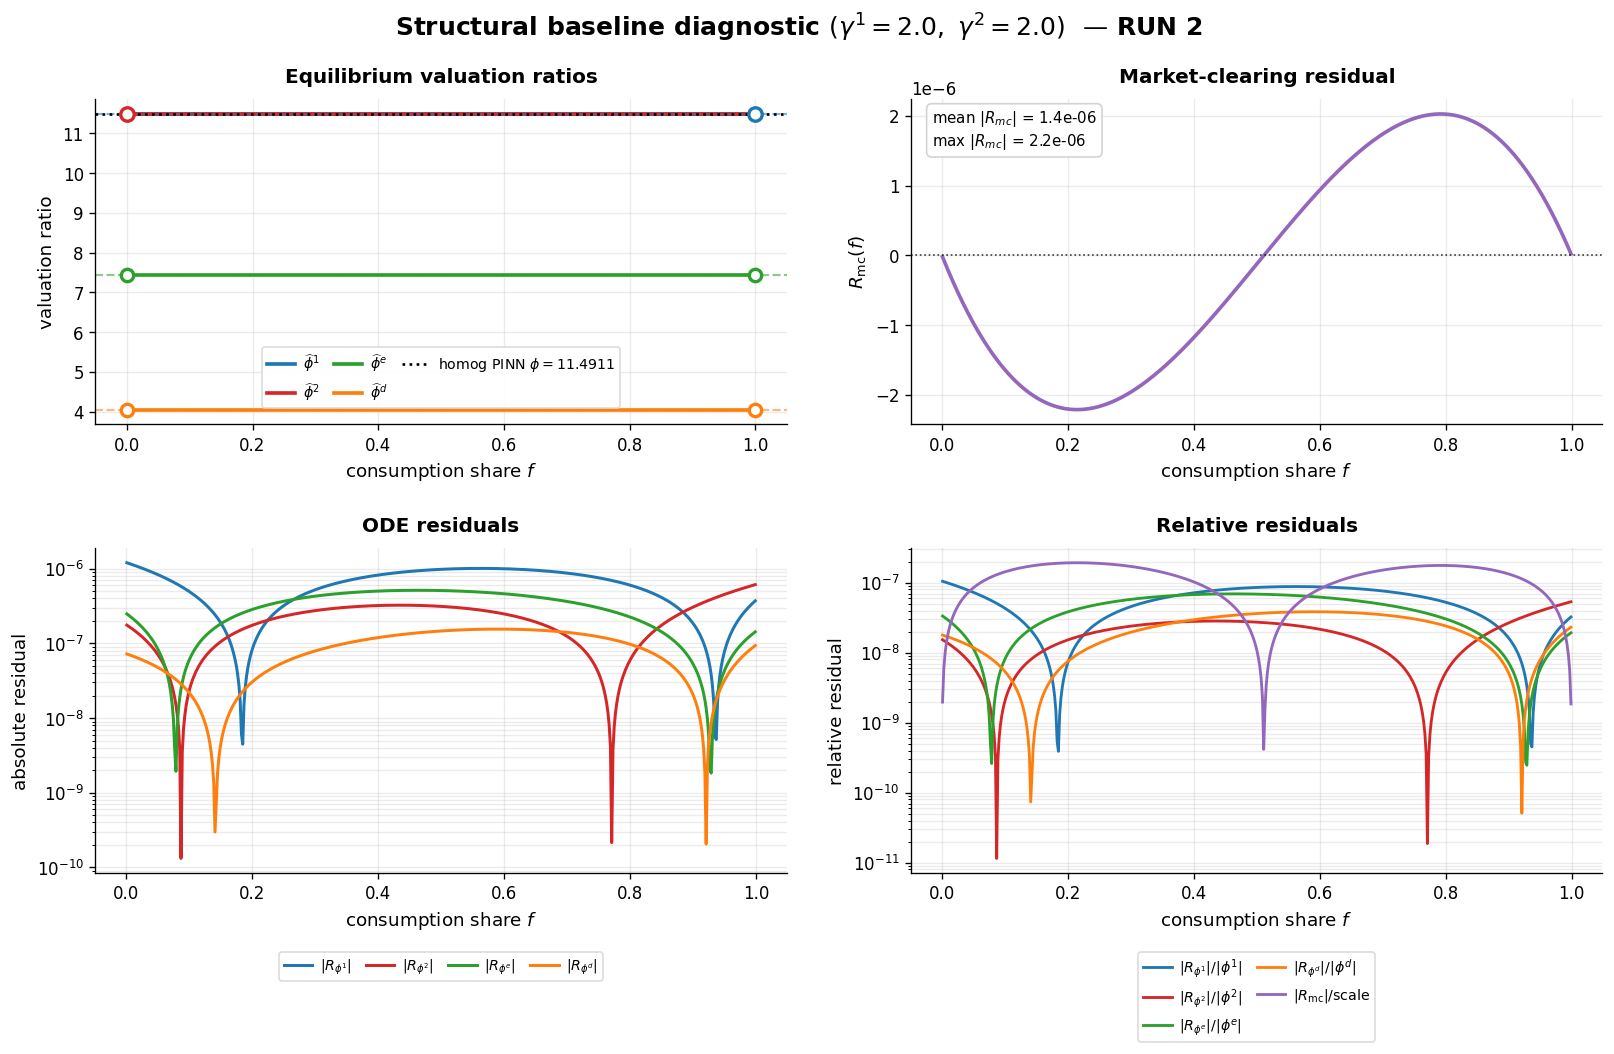

In [121]:
print('=' * 70)
print('RUN 2: γ¹ = γ² = 2 (homog CRRA)')
print('=' * 70)

net2, compute_residuals2, constants2 = setup_run(gamma1=2.0, gamma2=2.0)
print(f'  Anchors: φ={constants2["PHI1_INF"]:.4f}, φᵉ={constants2["PHIE_L"]:.4f}, φᵈ={constants2["PHID_L"]:.4f}')
print(f'  β_homog(2) = {constants2["b1_homog"]:.4f}')

history2, final_loss2 = train_run(net2, compute_residuals2, n_adam=2000, n_lbfgs=50)

# Load the standalone homog-CRRA PINN (if available) for three-way comparison.
phi_homog_crra = load_homog_pinn_and_extract_phi('value_net_phase2_CRRA.pt', gamma=2.0)

validate_run(net2, compute_residuals2, constants2, title_suffix=' — RUN 2',
             save_prefix='run2_homog_crra', homog_phi_pinn=phi_homog_crra)


---
## 5. Run 3 — True heterogeneous (γ¹ = 1, γ² = 2)

The production case: log agent + CRRA-2 agent. No closed-form solution
exists; this is the actual result of the methodology.

Expected:
- Boundary anchors machine-exact (by lifting)
- Off-side values: $\phi^1(0)$ near 14.286 (log invariance), $\phi^2(1)$ somewhere around 12-13
- Residuals: should be lower than the generic-lifting case if structural
  baseline helps


RUN 3: γ¹ = 1, γ² = 2 (true heterogeneous, production)
  Anchors: φ¹(1)=14.2857, φ²(0)=11.4878
           φᵉ(0)=7.4391, φᵉ(1)=9.0525
           φᵈ(0)=4.0487, φᵈ(1)=5.2332
  β_homog(γ¹=1) = 0.6337, β_homog(γ²=2) = 0.6476
  Adam: 3000 ep, lr=0.0001, N_coll=4000, w(agent,asset,mc)=(1.0,1.0,0.5)
    ep     1  loss=3.8644e-03  L1²=1.08e-12  L2²=1.20e-03  Le²=1.91e-05  Ld²=8.52e-06  mc²=5.27e-03
    ep   200  loss=3.2574e-04  L1²=3.58e-06  L2²=1.31e-04  Le²=1.28e-05  Ld²=6.74e-06  mc²=3.43e-04
    ep   400  loss=1.3531e-04  L1²=7.09e-07  L2²=4.74e-05  Le²=7.38e-06  Ld²=5.35e-06  mc²=1.49e-04
    ep   600  loss=3.0285e-05  L1²=8.46e-09  L2²=1.66e-05  Le²=4.44e-06  Ld²=3.34e-06  mc²=1.18e-05
    ep   800  loss=2.4720e-05  L1²=2.18e-08  L2²=1.21e-05  Le²=3.88e-06  Ld²=2.87e-06  mc²=1.16e-05
    ep  1000  loss=2.1575e-05  L1²=1.26e-08  L2²=9.77e-06  Le²=3.49e-06  Ld²=2.66e-06  mc²=1.13e-05
    ep  1200  loss=1.8621e-05  L1²=1.81e-09  L2²=7.79e-06  Le²=3.21e-06  Ld²=2.39e-06  mc²=1.05e-05
    ep 

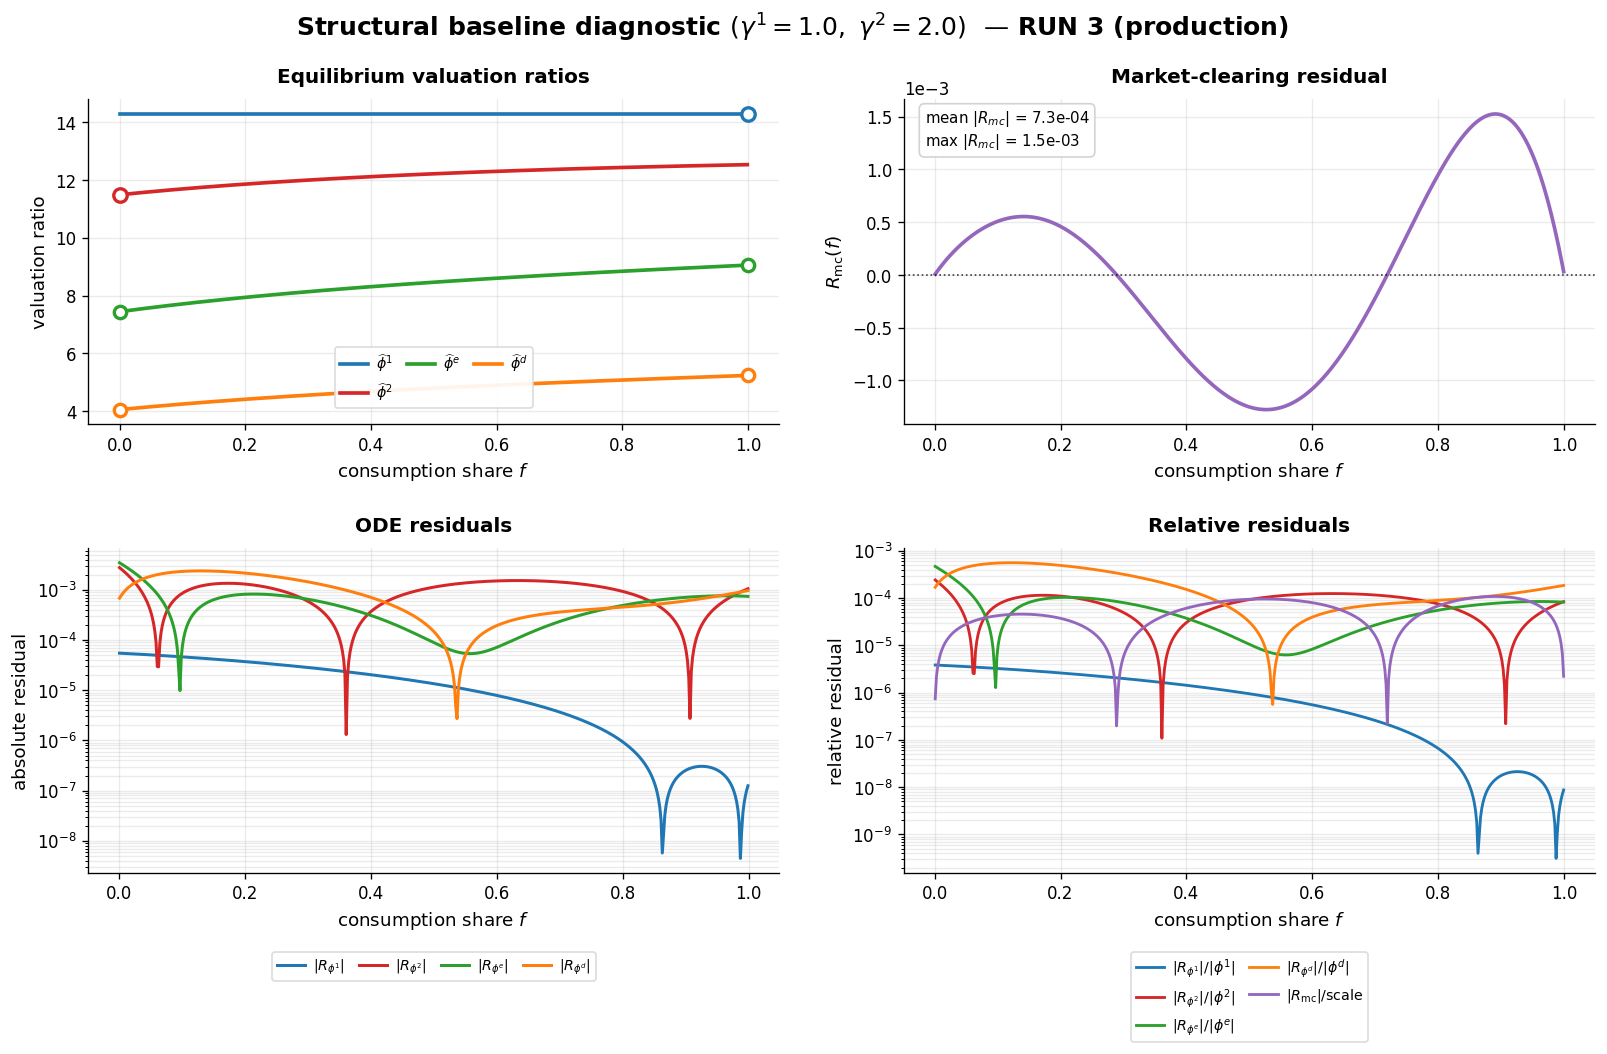

In [122]:
print('=' * 70)
print('RUN 3: γ¹ = 1, γ² = 2 (true heterogeneous, production)')
print('=' * 70)

net3, compute_residuals3, constants3 = setup_run(gamma1=1.0, gamma2=2.0)
print(f'  Anchors: φ¹(1)={constants3["PHI1_INF"]:.4f}, φ²(0)={constants3["PHI2_INF"]:.4f}')
print(f'           φᵉ(0)={constants3["PHIE_L"]:.4f}, φᵉ(1)={constants3["PHIE_R"]:.4f}')
print(f'           φᵈ(0)={constants3["PHID_L"]:.4f}, φᵈ(1)={constants3["PHID_R"]:.4f}')
print(f'  β_homog(γ¹=1) = {constants3["b1_homog"]:.4f}, β_homog(γ²=2) = {constants3["b2_homog"]:.4f}')

history3, final_loss3 = train_run(net3, compute_residuals3, n_adam=3000, n_lbfgs=100)
validate_run(net3, compute_residuals3, constants3, title_suffix=' — RUN 3 (production)', save_prefix='run3_het_log_crra')


---
## 6. Cross-run summary

Comparison of total losses across the three runs gives a quick sanity
check that the implementation works:
- Runs 1 and 2 (homog limits) should have lower loss than Run 3
- All three should reach final loss $\lesssim 10^{-4}$


In [123]:
print('=' * 70)
print('SUMMARY OF ALL RUNS')
print('=' * 70)
print(f'  Run 1 (γ¹=γ²=1, homog log):  final loss = {final_loss1:.6e}')
print(f'  Run 2 (γ¹=γ²=2, homog CRRA): final loss = {final_loss2:.6e}')
print(f'  Run 3 (γ¹=1, γ²=2, het):     final loss = {final_loss3:.6e}')

# Save the production network
torch.save(net3.state_dict(), 'net_het_structBaseline_g1_g2.pt')
print(f'\nSaved production network -> net_het_structBaseline_g1_g2.pt')


SUMMARY OF ALL RUNS
  Run 1 (γ¹=γ²=1, homog log):  final loss = 1.612342e-12
  Run 2 (γ¹=γ²=2, homog CRRA): final loss = 1.779558e-12
  Run 3 (γ¹=1, γ²=2, het):     final loss = 5.085992e-06

Saved production network -> net_het_structBaseline_g1_g2.pt
